In [1]:
import numpy as np
import pandas as pd

In [2]:
# 设置随机种子
np.random.seed(42)

# 生成400个样本
n_samples = 400

# 生成特征
# 1. 房屋面积 (平方米)
area = np.random.uniform(50, 200, n_samples)

# 2. 卧室数量
bedrooms = np.random.choice([1, 2, 3, 4, 5], n_samples, p=[0.1, 0.3, 0.4, 0.15, 0.05])

# 3. 房龄 (年)
age = np.random.exponential(10, n_samples)
age = np.clip(age, 0, 50)  # 限制在0-50年

# 4. 地理位置评分 (1-10分)
location = np.random.normal(6, 2, n_samples)
location = np.clip(location, 1, 10)

# 生成目标变量：房价 (万元)
# 真实关系：price = 0.8*area + 15*bedrooms - 0.5*age + 8*location + 30 + noise
noise = np.random.normal(0, 20, n_samples)
price = 0.8 * area + 15 * bedrooms - 0.5 * age + 8 * location + 30 + noise

# 创建DataFrame
data = pd.DataFrame({
    'area': area,
    'bedrooms': bedrooms,
    'age': age,
    'location': location,
    'price': price
})


In [68]:
rng_divide=np.random.default_rng(17)

data_train=data.sample(frac=0.67,random_state=rng_divide)
data_test=data.sample(frac=0.33)
data_train.head()

,area,bedrooms,age,location,price
186,172.583330,1,11.660427,6.300838,225.989540
365,107.915396,3,17.035674,7.676982,187.310738
26,79.951067,3,4.251771,5.835698,171.990341
39,116.022874,1,10.003908,9.601881,190.966033
281,100.699274,2,0.936636,9.499153,211.037258


In [69]:
#normalize
Mean=data_train.mean(axis=0)
Std=data_train.std(axis=0)
dataTrain_normalized=(data_train-Mean)/Std  #can be optimized
dataTrain_normalized.head()

,area,bedrooms,age,location,price
186,1.123428,-1.748388,0.232495,0.126271,0.238032
365,-0.307932,0.280045,0.803037,0.843644,-0.588638
26,-0.926894,0.280045,-0.553880,-0.116203,-0.916077
39,-0.128481,-1.748388,0.056667,1.847079,-0.510515
281,-0.467653,-0.734172,-0.905757,1.793528,-0.081539


In [5]:
def sigmoid(x):
    return 1/(1+np.exp(-x))

In [6]:
def get_loss(y,y_hat):
    return 1/2*pow((y_hat-y),2)

In [7]:
def upgrade_parameter(y,y_hat,x,level_1_to_2,\
              primary_parameter,alph=1):
    
    
    g=y_hat-y
    delta_power2=-alph*g*level_1_to_2
    delta_threshold2=-alph*g

    e=level_1_to_2*(1-level_1_to_2)*primary_parameter['power2']*g    #对后两项，我这里只是一维的输出，power2是1*7的
    delta_power1=-alph*x.reshape(-1,1)@e.reshape(1,-1)    #e,xi都是向量，最后会做成一个4*7的
    delta_threshold1=-alph*(-e)

    primary_parameter['power2']+=delta_power2
    primary_parameter['threshold2']+=delta_threshold2
    primary_parameter['power1']+=delta_power1
    primary_parameter['threshold1']+=delta_threshold1

    return primary_parameter


In [8]:
def standard_BP(data,primary_parameter,loop):
    x=data.iloc[:-1].values
    y=data.iloc[-1]
    
    #input to level1
    level_1=x@primary_parameter['power1'] #向量，直接计算了内积
    #deal and output
    level_1_to_2=sigmoid(level_1-primary_parameter['threshold1'])
    

    #input to level2
    level_2=level_1_to_2@primary_parameter['power2']
    #deal and output
    
    
    y_hat=level_2+primary_parameter['threshold2'][0]    #why ?  #because array([1]) is not array(1)

    global loss_sum
    if loop%200==0:
        loss_sum+=get_loss(y,y_hat)
        print(f'mean loss:{(loss_sum/((loop/200)+1)):.6f}')

    primary_parameter=\
    upgrade_parameter(y,y_hat,x,level_1_to_2,\
                      primary_parameter,alph=0.1)
    
    return primary_parameter   

In [9]:
def test_standardBP(data_test,primary_parameter):
    x=data_test.iloc[:-1].values
    y=data_test.iloc[-1]
    
    #input to level1
    level_1=x@primary_parameter['power1'] #向量，直接计算了内积
    #deal and output
    level_1_to_2=sigmoid(level_1-primary_parameter['threshold1'])
   
    #input to level2
    level_2=level_1_to_2@primary_parameter['power2']
    #deal and output
    
   
    y_hat=level_2+primary_parameter['threshold2'][0]

    return y_hat

In [11]:
#Adaboost with Sigmoid BP,e Error
#

In [12]:
#start

In [13]:
D_1=np.array([1/len(data_train)]*len(data_train))
D_1[:5]

array([0.00373134, 0.00373134, 0.00373134, 0.00373134, 0.00373134])

In [14]:
dataTrain_1=dataTrain_normalized.sample(frac=1,weights=D_1,axis=0,random_state=17)
dataTrain_1=dataTrain_1.sample(frac=1,weights=D_1,axis=0,random_state=17)
dataTrain_1.head()

,area,bedrooms,age,location,price
361,0.545950,-0.734172,-0.858735,-2.275125,-0.640581
273,1.442218,0.280045,-0.986030,-0.478245,1.672914
52,1.529399,0.280045,-0.755099,0.788709,1.834651
332,-1.542043,0.280045,-0.915462,0.551549,-0.326408
245,1.492279,1.294262,0.010353,-0.095812,0.889724


In [15]:
#D_1=pd.DataFrame([1/len(data_train)]*len(data_train),index=dataTrain_1.index,columns=['weights'])
#D_1.head()


In [16]:
rng=np.random.default_rng(17)

primary_parameter={'power1':rng.random((4,7))*0.1,\
                   'threshold1':rng.random(7)*0.1,\
                   'power2':rng.random(7)*0.1,\
                   'threshold2':rng.random(1)*0.1}
print(primary_parameter)

{'power1': array([[0.08450748, 0.01609731, 0.05577445, 0.03680799, 0.0214942 ,
        0.0385824 , 0.04281645],
       [0.06113431, 0.07363859, 0.00152897, 0.02540409, 0.06041459,
        0.00837367, 0.09977637],
       [0.08323461, 0.00367774, 0.05675398, 0.06093401, 0.00069266,
        0.01790839, 0.01649222],
       [0.04619579, 0.05670036, 0.04519092, 0.09197757, 0.08149242,
        0.04011661, 0.02031616]]), 'threshold1': array([0.03583255, 0.0862035 , 0.03488156, 0.09910656, 0.05657688,
       0.02368459, 0.06586973]), 'power2': array([0.06602265, 0.05146076, 0.0279093 , 0.06299182, 0.04791908,
       0.06532888, 0.05422403]), 'threshold2': array([0.01212111])}


In [17]:
loss_sum=0
train_len=len(dataTrain_1)
for j in range(10):
    for i in range(train_len):
        loop=train_len*j+i
        primary_parameter=\
        standard_BP(dataTrain_1.iloc[i],primary_parameter,loop)
print(primary_parameter)

mean loss:0.335834
mean loss:0.171359
mean loss:0.136526
mean loss:0.125209
mean loss:0.177921
mean loss:0.149762
mean loss:0.134921
mean loss:0.132576
mean loss:0.138929
mean loss:0.151402
mean loss:0.140865
mean loss:0.135559
mean loss:0.138585
mean loss:0.130025
{'power1': array([[ 1.43501667,  0.35441107, -0.4972901 ,  0.6550223 ,  0.40913072,
         0.29357774,  0.6125709 ],
       [-0.41039873,  0.36240739, -0.59793815,  0.43849084,  0.39630438,
         0.22296133,  0.67309241],
       [-0.22496343, -0.09665849,  0.28525922, -0.033853  , -0.10814515,
        -0.07922432,  0.02187302],
       [ 0.31327804,  0.31888506, -0.31457743,  0.27802932,  0.33900103,
         0.300214  ,  0.24890239]]), 'threshold1': array([0.25355424, 0.50629756, 0.56970573, 0.4887003 , 0.47118017,
       0.47474559, 0.43937119]), 'power2': array([ 1.35599324,  0.44994186, -0.87808946,  0.76150964,  0.52428707,
        0.3151308 ,  0.85663823]), 'threshold2': array([-1.38029227])}


In [18]:
dataTrain1_preduction=dataTrain_1.apply(test_standardBP,\
                                           axis=1,args=(primary_parameter,))
dataTrain1_preduction.head()

361   -0.353095
273    1.300146
52     1.678476
332   -0.768131
245    1.619921
dtype: float64

In [19]:
np.mean(abs(dataTrain1_preduction-dataTrain_normalized['price']))

np.float64(0.3557760688593842)

In [20]:
wrong=abs(dataTrain_1['price']-dataTrain1_preduction)>0.5  #epsilon need to greater than 0.5?
epsilon=np.sum(wrong*D_1)
print(epsilon)

0.25373134328358204


In [21]:
#if epsilon > n    break

In [22]:
alpha=1/2*np.log((1-epsilon)/epsilon)/np.log(np.e)
alpha

np.float64(0.5394048306859651)

In [23]:
right=abs(dataTrain_1['price']-dataTrain1_preduction)<0.5
value_right=right.astype(int)
value_right[~right]=-1
D_1=(D_1*np.exp(value_right*alpha)).values
D_1[:5]

array([0.0063992 , 0.0063992 , 0.0063992 , 0.0063992 , 0.00217573])

In [24]:
#Here is the formal

In [53]:
rng=np.random.default_rng(20)
train_len=len(data_train)

D_1=np.array([1/len(data_train)]*len(data_train))
dataTrain_1=dataTrain_normalized.sample(frac=1,weights=D_1,axis=0,random_state=17)

list_alpha=[]
list_parameter=[]
number=0

rOrw=0.45

for t in range(17):
    primary_parameter={'power1':rng.random((4,7))*0.1,\
                   'threshold1':rng.random(7)*0.1,\
                   'power2':rng.random(7)*0.1,\
                   'threshold2':rng.random(1)*0.1}
    loss_sum=0
    
    for j in range(10):
        for i in range(train_len):
            loop=train_len*j+i
            primary_parameter=\
            standard_BP(dataTrain_1.iloc[i],primary_parameter,loop)
    print(primary_parameter)
    
    dataTrain1_preduction=dataTrain_1.apply(test_standardBP,\
                                           axis=1,args=(primary_parameter,))

    
    wrong=abs(dataTrain_1['price']-dataTrain1_preduction)>rOrw
    epsilon=np.sum(wrong*D_1)
    # 防止除零错误
    epsilon = max(epsilon, 1e-10)
    print(epsilon)
    
    if epsilon>0.5:
        print("This loop was failed and it restarted\n")
        number+=rng.integers(1,10)
        continue
    
    alpha=1/2*np.log((1-epsilon)/epsilon)  #np.log means ln

    list_parameter.append(primary_parameter)
    list_alpha.append(alpha)

    right=abs(dataTrain_1['price']-dataTrain1_preduction)<rOrw
    value_right=right.astype(int)
    value_right[~right]=-1
    
    D_1=(D_1*np.exp(value_right*alpha)).values  #value_right is a Series ,and the the D_1 become a Series to.
    D_1=D_1/np.sum(D_1)#Although the sample can normalize the weights,but the normalized D_1 will infect the next train
    dataTrain_1=dataTrain_normalized.sample(frac=1,replace=True,weights=D_1,axis=0,random_state=17+number)
    #But if a Series,the index of the weights of sample can't be duplicated
    ##there sample from dataTrain_normalized,not dataTrain_1

mean loss:1.650224
mean loss:0.917296
mean loss:0.612414
mean loss:0.460871
mean loss:0.373464
mean loss:0.372039
mean loss:0.354745
mean loss:0.324331
mean loss:0.315337
mean loss:0.286546
mean loss:0.271814
mean loss:0.252092
mean loss:0.278970
mean loss:0.259078
{'power1': array([[ 0.6740315 ,  0.76121959, -0.92023011,  0.96157329,  0.04901666,
        -0.03004409, -0.75688368],
       [ 0.59199449,  0.43203711, -0.13021592,  0.19999556,  0.02400365,
        -0.02089766, -0.32789578],
       [ 0.09620535,  0.07718918,  0.23028227,  0.06285779,  0.08252861,
         0.0733298 ,  0.23809231],
       [ 0.17155778,  0.18897739, -0.48197636,  0.21452067,  0.09737317,
         0.05590258, -0.44177383]]), 'threshold1': array([0.62542719, 0.57762012, 0.49478338, 0.58308155, 0.4478904 ,
       0.47251568, 0.53138575]), 'power2': array([ 0.95578442,  0.95337191, -1.01401827,  1.08671615,  0.04706907,
       -0.02868261, -0.92517947]), 'threshold2': array([-0.48564539])}
0.29850746268656714
me

In [54]:
#check

count=len(list_alpha)
print(f"We did {count} basic learner")
alpha_sum=sum(list_alpha)
preduction=pd.Series(np.zeros(len(dataTrain_normalized)),index=dataTrain_normalized.index)


for t in range(count):
    output_alpha=list_alpha[t]/alpha_sum

    preduction+=output_alpha*dataTrain_normalized.apply(test_standardBP,axis=1,args=(list_parameter[t],))


preduction.head()

We did 17 basic learner


186    0.303790
365    0.016301
26    -0.716307
39     0.128155
281    0.248490
dtype: float64

In [55]:
dataTrain_normalized.head()

,area,bedrooms,age,location,price
186,1.123428,-1.748388,0.232495,0.126271,0.238032
365,-0.307932,0.280045,0.803037,0.843644,-0.588638
26,-0.926894,0.280045,-0.553880,-0.116203,-0.916077
39,-0.128481,-1.748388,0.056667,1.847079,-0.510515
281,-0.467653,-0.734172,-0.905757,1.793528,-0.081539


In [56]:
np.mean(abs(preduction-dataTrain_normalized['price']))

np.float64(0.3468238553821198)

In [628]:
#test

In [57]:
dataTest_normalized=(data_test-Mean)/Std
dataTest_normalized.head()

,area,bedrooms,age,location,price
57,-0.939148,0.280045,-0.327150,-1.238247,-0.942030
208,-1.573026,0.280045,-0.700290,1.209570,-0.499643
96,0.145694,0.280045,-0.636929,1.770556,0.339515
258,0.302829,0.280045,-0.311333,-1.054880,0.023416
229,0.505612,-0.734172,0.868878,2.054616,0.341808


In [58]:
count=len(list_alpha)
alpha_sum=sum(list_alpha)
test_preduction=pd.Series(np.zeros(len(dataTest_normalized)),index=dataTest_normalized.index)


for t in range(count):
    output_alpha=list_alpha[t]/alpha_sum

    test_preduction+=output_alpha*dataTest_normalized.apply(test_standardBP,axis=1,args=(list_parameter[t],))


test_preduction.head()

57    -1.154348
208   -0.661753
96     0.958459
258   -0.116261
229    0.848144
dtype: float64

In [59]:
final_testPreduction=test_preduction*Std['price']+Mean['price']
final_testPreduction.name='price_preduction'
#final_testPreduction.head()

In [60]:
result=pd.concat([data_test['price'],final_testPreduction],axis=1)
print(result.head())

          price  price_preduction
57   170.776031        160.841932
208  191.474722        183.889813
96   230.737778        259.697358
258  215.947937        209.412669
229  230.845068        254.535870


In [61]:
import matplotlib.pyplot as plt
%matplotlib inline

<Axes: xlabel='price', ylabel='price_preduction'>

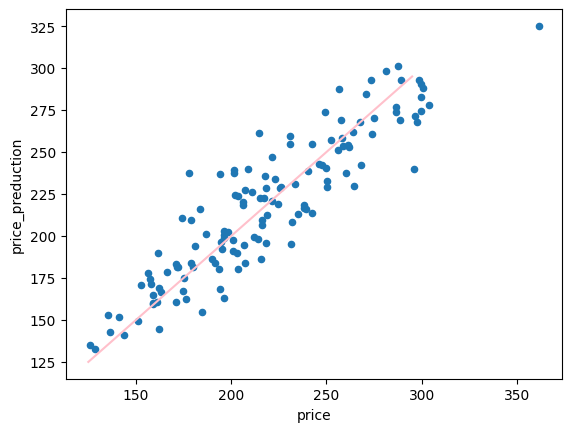

In [62]:
result.plot(kind='scatter',x='price',y='price_preduction')
xy=pd.Series(np.arange(125,300,10),index=np.arange(125,300,10))
xy.plot(kind='line',color='pink')


In [63]:
MeanSqu_error=pow(result['price']-result['price_preduction'],2).mean()
print(f'Mean Squared Error:{MeanSqu_error}')
print(f'Root Mean Squared Error:{pow(MeanSqu_error,0.5)}')

Mean Squared Error:376.3972573896941
Root Mean Squared Error:19.40096021823905


In [637]:
#it performed better than just one Sigmoid BP.And if relay on the threshold of right or wrong(rOrw).
#While,this method is not so good.

In [641]:
#bagging

In [65]:
def bagging_standard_BP(data,primary_parameter,loop):
    x=data.iloc[:-1].values
    y=data.iloc[-1]
    
    #input to level1
    level_1=x@primary_parameter['power1'] #向量，直接计算了内积
    #deal and output
    level_1_to_2=sigmoid(level_1-primary_parameter['threshold1'])
    

    #input to level2
    level_2=level_1_to_2@primary_parameter['power2']
    #deal and output
    
    
    y_hat=level_2+primary_parameter['threshold2'][0]    #why ?  #because array([1]) is not array(1)

    global bagging_loss_sum
    if loop%1500==0:
        bagging_loss_sum+=get_loss(y,y_hat)
        print(f'mean loss:{(bagging_loss_sum/((loop/1500)+1)):.6f}')

    primary_parameter=\
    upgrade_parameter(y,y_hat,x,level_1_to_2,\
                      primary_parameter,alph=0.1)
    
    return primary_parameter   

In [66]:
rng=np.random.default_rng(177)
learner=25
bagging_train_len=len(dataTrain_normalized)
bagging_list_parameter=[]

for i in range(learner):  #loop 50 or 10 didn't have a great change
    print(f"learner {i}")
    bagging_loss_sum=0
    bagging_train=dataTrain_normalized.sample(frac=1,replace=True)
    bagging_primary_parameter={'power1':rng.random((4,7))*0.1,\
                   'threshold1':rng.random(7)*0.1,\
                   'power2':rng.random(7)*0.1,\
                   'threshold2':rng.random(1)*0.1}
    for j in range(10):
        for i in range(bagging_train_len):
            loop=bagging_train_len*j+i
            bagging_primary_parameter=\
            bagging_standard_BP(bagging_train.iloc[i],bagging_primary_parameter,loop)
    bagging_list_parameter.append(bagging_primary_parameter)
    
    

learner 0
mean loss:0.720838
mean loss:0.417550
learner 1
mean loss:0.249398
mean loss:0.149597
learner 2
mean loss:0.961596
mean loss:0.573401
learner 3
mean loss:0.001434
mean loss:0.000750
learner 4
mean loss:0.166993
mean loss:0.176774
learner 5
mean loss:0.337595
mean loss:0.168922
learner 6
mean loss:0.005116
mean loss:0.050182
learner 7
mean loss:0.094230
mean loss:0.082053
learner 8
mean loss:0.061171
mean loss:0.045348
learner 9
mean loss:0.878249
mean loss:0.490137
learner 10
mean loss:0.053476
mean loss:0.132319
learner 11
mean loss:0.000003
mean loss:0.082002
learner 12
mean loss:0.018770
mean loss:0.009386
learner 13
mean loss:0.005284
mean loss:0.019841
learner 14
mean loss:0.461535
mean loss:0.231803
learner 15
mean loss:1.074139
mean loss:0.577334
learner 16
mean loss:0.819669
mean loss:0.453160
learner 17
mean loss:0.977911
mean loss:0.566914
learner 18
mean loss:0.659542
mean loss:0.375400
learner 19
mean loss:0.098406
mean loss:0.079675
learner 20
mean loss:0.297497


In [77]:
dataTest_normalized=(data_test-Mean)/Std
dataTest_normalized.head()

,area,bedrooms,age,location,price
44,-0.730656,1.294262,-0.834340,0.845888,-0.440090
286,-0.043999,0.280045,0.003600,-0.338064,-0.193665
93,0.273665,-0.734172,-0.467941,-0.628685,0.218881
45,0.609809,1.294262,-0.436779,-0.710970,-0.058569
299,-1.306469,0.280045,-0.547725,-0.183816,-0.438081


In [78]:
bagging_test_preduction=pd.Series(np.zeros(len(dataTest_normalized)),index=dataTest_normalized.index)
for i in range(learner):
    bagging_test_preduction+=dataTest_normalized.apply(test_standardBP,axis=1,args=(bagging_list_parameter[i],))
bagging_test_preduction=bagging_test_preduction/learner
bagging_test_preduction.head()

44     0.235819
286   -0.080743
93    -0.227820
45     0.767452
299   -0.924166
dtype: float64

In [79]:
bagging_final_testPreduction=bagging_test_preduction*Std['price']+Mean['price']
bagging_final_testPreduction.name='bagging_price_preduction'
result=pd.concat([data_test['price'],bagging_final_testPreduction],axis=1)
print(result.head())

          price  bagging_price_preduction
44   194.261137                225.885992
286  205.790998                211.074478
93   225.093498                204.192952
45   212.111957                250.760377
299  194.355113                171.611857


<Axes: xlabel='price', ylabel='bagging_price_preduction'>

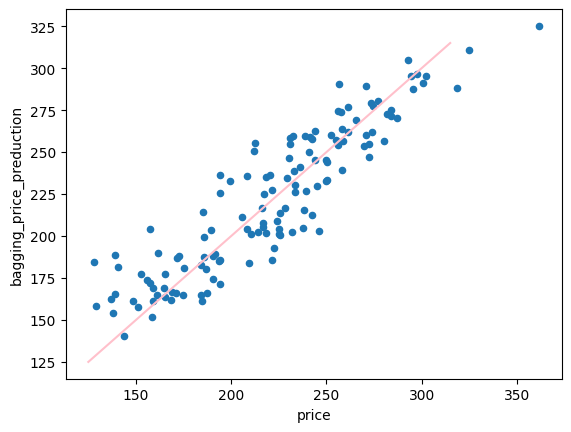

In [82]:
result.plot(kind='scatter',x='price',y='bagging_price_preduction')
xy=pd.Series(np.arange(125,325,10),index=np.arange(125,325,10))
xy.plot(kind='line',color='pink')

In [81]:
MeanSqu_error=pow(result['price']-result['bagging_price_preduction'],2).mean()
print(f'Mean Squared Error:{MeanSqu_error}')
print(f'Root Mean Squared Error:{pow(MeanSqu_error,0.5)}')

Mean Squared Error:389.57180836381406
Root Mean Squared Error:19.737573517629112
